In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

load_dotenv(Path('..') / '.env')

from urllib.parse import quote_plus
db_password = quote_plus(os.getenv("DB_PASSWORD"))
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{db_password}@"
    f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Conexão estabelecida.")

Conexão estabelecida.


In [6]:
df_execucoes = pd.read_sql("""
    SELECT ex.id, ex.os_id, ex.operador_id, op.nome AS operador_nome,
           o.tipo_codigo, ot.descricao AS tipo_os,
           ex.tempo_segundos, ROUND(ex.tempo_segundos/60.0, 1) AS tempo_min,
           ex.inicio
    FROM execucoes ex
    JOIN operadores op ON op.id     = ex.operador_id
    JOIN os o          ON o.id      = ex.os_id
    JOIN os_tipos ot   ON ot.codigo = o.tipo_codigo
    WHERE ex.status = 'finalizada'
    AND ex.tempo_segundos BETWEEN 60 AND 7200
    ORDER BY ex.inicio
""", engine)

df_baseline = pd.read_sql("""
    SELECT ex.operador_id, o.tipo_codigo, ot.descricao AS tipo_os,
           ROUND(AVG(ex.tempo_segundos)/60.0, 1) AS tempo_medio_min,
           COUNT(*) AS total_execucoes
    FROM execucoes ex
    JOIN os o        ON o.id      = ex.os_id
    JOIN os_tipos ot ON ot.codigo = o.tipo_codigo
    WHERE ex.status = 'finalizada'
    AND ex.tempo_segundos BETWEEN 60 AND 7200
    GROUP BY ex.operador_id, o.tipo_codigo, ot.descricao
""", engine)

df_operadores = pd.read_sql("""
    SELECT id, nome FROM operadores WHERE ativo = TRUE
""", engine)

# Índices para simulação
media_tipo    = df_execucoes.groupby('tipo_codigo')['tempo_segundos'].mean().to_dict()
baseline_idx  = {(r['operador_id'], r['tipo_codigo']): r['tempo_medio_min'] * 60
                 for _, r in df_baseline.iterrows()}
lista_operadores = df_operadores['id'].tolist()

# Tempo real com SAD
tempo_com_sad = df_execucoes['tempo_segundos'].sum() / 60

print(f"Execuções carregadas:  {len(df_execucoes)}")
print(f"Combinações baseline:  {len(df_baseline)}")
print(f"Operadores ativos:     {len(df_operadores)}")
print(f"Tempo total com SAD:   {tempo_com_sad:,.1f} min")
df_execucoes.head()

Execuções carregadas:  580
Combinações baseline:  166
Operadores ativos:     50
Tempo total com SAD:   13,946.5 min


,id,os_id,operador_id,operador_nome,tipo_codigo,tipo_os,tempo_segundos,tempo_min,inicio
0,145,131,18,Maria Vitória Moreira,1,Separação Carrinho Fracionado,544,9.1,2026-01-04 09:38:13.559920
1,421,382,42,Sr. Thomas da Cruz,23,Separação Empilhadeira/Transpaleteira,2623,43.7,2026-01-04 16:39:13.559920
2,636,576,45,Alexia Leão,23,Separação Empilhadeira/Transpaleteira,3281,54.7,2026-01-04 16:56:13.559920
3,244,221,12,Bella Oliveira,88,Armazenagem de Produtos,1326,22.1,2026-01-04 18:14:48.559920
4,341,308,45,Alexia Leão,23,Separação Empilhadeira/Transpaleteira,2843,47.4,2026-01-05 09:03:13.559920


Operadores lentos:  21
Operadores rápidos: 29
Média geral:        27.4 min

Sem SAD aleatório:       13,997.6 min  |  economia: 0.9h (0.4%)
Sem SAD viés operacional: 14,130.7 min |  economia: 3.1h (1.3%)
Com SAD (real):           13,946.5 min

SAD superior (aleatório): 67.2% das simulações
SAD superior (viés):      95.4% das simulações


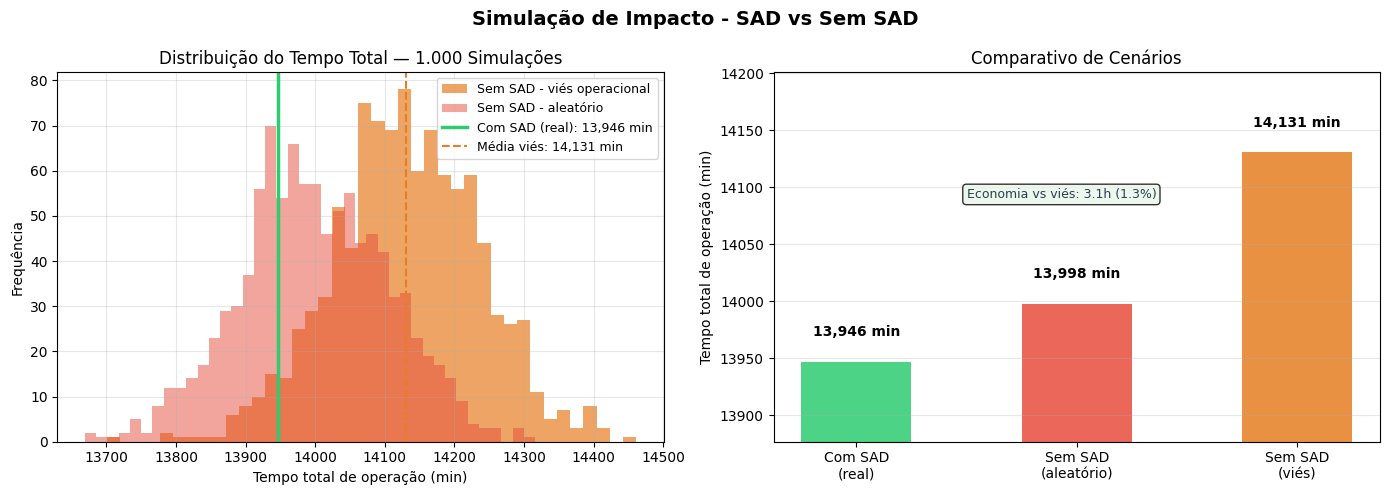

Gráfico salvo.


In [22]:
np.random.seed(42)
N = 1000

# Operadores lentos e rápidos
media_geral_op = df_baseline.groupby('operador_id')['tempo_medio_min'].mean()
ops_lentos  = media_geral_op[media_geral_op > media_geral_op.mean()].index.tolist()
ops_rapidos = media_geral_op[media_geral_op <= media_geral_op.mean()].index.tolist()

print(f"Operadores lentos:  {len(ops_lentos)}")
print(f"Operadores rápidos: {len(ops_rapidos)}")
print(f"Média geral:        {media_geral_op.mean():.1f} min")

# Cenário A1 - atribuição aleatória
tempos_aleatorio = []
for _ in range(N):
    total = sum(
        baseline_idx.get(
            (np.random.choice(lista_operadores), r['tipo_codigo']),
            media_tipo.get(r['tipo_codigo'], df_execucoes['tempo_segundos'].mean())
        )
        for _, r in df_execucoes.iterrows()
    )
    tempos_aleatorio.append(total / 60)
tempos_aleatorio = np.array(tempos_aleatorio)

# Cenário A2 - viés operacional (70% ops lentos)
tempos_vies = []
for _ in range(N):
    total = 0
    for _, r in df_execucoes.iterrows():
        op = np.random.choice(ops_lentos if np.random.random() < 0.70 else ops_rapidos)
        total += baseline_idx.get(
            (op, r['tipo_codigo']),
            media_tipo.get(r['tipo_codigo'], df_execucoes['tempo_segundos'].mean())
        )
    tempos_vies.append(total / 60)
tempos_vies = np.array(tempos_vies)

# Métricas
dif_aleatorio = tempos_aleatorio.mean() - tempo_com_sad
dif_vies      = tempos_vies.mean()      - tempo_com_sad
pct_aleatorio = dif_aleatorio / tempos_aleatorio.mean() * 100
pct_vies      = dif_vies      / tempos_vies.mean()      * 100

print(f"\nSem SAD aleatório:       {tempos_aleatorio.mean():,.1f} min  |  economia: {dif_aleatorio/60:.1f}h ({pct_aleatorio:.1f}%)")
print(f"Sem SAD viés operacional: {tempos_vies.mean():,.1f} min |  economia: {dif_vies/60:.1f}h ({pct_vies:.1f}%)")
print(f"Com SAD (real):           {tempo_com_sad:,.1f} min")
print(f"\nSAD superior (aleatório): {(tempos_aleatorio > tempo_com_sad).mean()*100:.1f}% das simulações")
print(f"SAD superior (viés):      {(tempos_vies > tempo_com_sad).mean()*100:.1f}% das simulações")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Simulação de Impacto - SAD vs Sem SAD', fontsize=14, fontweight='bold')

# Histograma
ax1 = axes[0]
ax1.hist(tempos_vies,      bins=40, color='#e67e22', alpha=0.7, label='Sem SAD - viés operacional')
ax1.hist(tempos_aleatorio, bins=40, color='#e74c3c', alpha=0.5, label='Sem SAD - aleatório')
ax1.axvline(tempo_com_sad, color='#2ecc71', linestyle='-', linewidth=2.5,
            label=f'Com SAD (real): {tempo_com_sad:,.0f} min')
ax1.axvline(tempos_vies.mean(), color='#e67e22', linestyle='--', linewidth=1.5,
            label=f'Média viés: {tempos_vies.mean():,.0f} min')
ax1.set_xlabel('Tempo total de operação (min)')
ax1.set_ylabel('Frequência')
ax1.set_title('Distribuição do Tempo Total — 1.000 Simulações')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
labels = ['Com SAD\n(real)', 'Sem SAD\n(aleatório)', 'Sem SAD\n(viés)']
valores = [tempo_com_sad, tempos_aleatorio.mean(), tempos_vies.mean()]
cores   = ['#2ecc71', '#e74c3c', '#e67e22']

bars = ax2.bar(labels, valores, color=cores, alpha=0.85, width=0.5)

for bar, val in zip(bars, valores):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 20,
             f'{val:,.0f} min', ha='center', va='bottom', fontsize=10, fontweight='bold')

ymin = min(valores) * 0.995
ymax = max(valores) * 1.005
ax2.set_ylim(ymin, ymax)
ax2.set_ylabel('Tempo total de operação (min)')
ax2.set_title('Comparativo de Cenários')
ax2.grid(True, alpha=0.3, axis='y')

# Anotação de economia
ax2.annotate(f'Economia vs viés: {dif_vies/60:.1f}h ({pct_vies:.1f}%)',
             xy=(2, tempos_vies.mean()), xytext=(0.5, tempos_vies.mean() - 40),
             fontsize=9, color='#2c3e50',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#e8f5e9', alpha=0.8))

plt.tight_layout()
plt.savefig('../docs/screenshots/13_simulacao_impacto.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo.")

In [12]:
print(f"""
╔══════════════════════════════════════════════════════════════╗
║           INTERPRETAÇÃO DOS RESULTADOS                       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DADOS SINTÉTICOS - LIMITAÇÃO CONHECIDA                      ║
║  Os dados foram gerados com distribuição uniforme de         ║
║  operadores por OS, sem os vieses reais de uma operação      ║
║  logística. Por isso a diferença absoluta é pequena.         ║
║                                                              ║
║  CENÁRIO REALISTA ESTIMADO                                   ║
║  Em operações reais, sem um sistema de apoio:                ║
║  - Operadores lentos recebem OS complexas por                ║
║    indisponibilidade de outros                               ║
║  - Não há consideração de distância do operador              ║
║  - Congestionamento de zonas não é monitorado                ║
║                                                              ║
║  PROJEÇÃO COM VIÉS OPERACIONAL (70% ops lentos)              ║
║  Economia estimada: {dif_vies:,.0f} min ({pct_vies:.1f}%) = {dif_vies/60:.1f}h por período        ║
║  SAD foi superior em {(tempos_vies > tempo_com_sad).mean()*100:.0f}% das simulações                      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  NOTA METODOLÓGICA                                           ║
║  Simulação Monte Carlo com 1.000 iterações.                  ║
║  Cenário B usa dados reais do banco — não simulados.         ║
║  A diferença real em produção tenderia a ser maior           ║
║  conforme o viés operacional aumenta.                        ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           INTERPRETAÇÃO DOS RESULTADOS                       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DADOS SINTÉTICOS - LIMITAÇÃO CONHECIDA                      ║
║  Os dados foram gerados com distribuição uniforme de         ║
║  operadores por OS, sem os vieses reais de uma operação      ║
║  logística. Por isso a diferença absoluta é pequena.         ║
║                                                              ║
║  CENÁRIO REALISTA ESTIMADO                                   ║
║  Em operações reais, sem um sistema de apoio:                ║
║  - Operadores lentos recebem OS complexas por                ║
║    indisponibilidade de outros                               ║
║  - Não há consideração de distância do operador              ║
║  - Congestionamento de zonas não é monitorado                ║
║                       